# Disease Prediction from Medical Data — CodeAlpha Machine Learning Internship
### Task 4: Predict the possibility of disease using structured patient data

**Objective:** Build a classification model that predicts whether a tumor is **malignant (cancerous)** or **benign (non-cancerous)** from diagnostic measurements taken from patient cell samples.

**Approach:** SVM, Logistic Regression, Random Forest, and XGBoost — compared using Precision, Recall, F1-Score, and ROC-AUC, exactly as listed in the task brief.

**Author:** Deval Patel
**Internship:** CodeAlpha — Machine Learning
**Repository name (as per instructions):** `CodeAlpha_DiseasePrediction`

---

**About the dataset:** This notebook uses the **Wisconsin Breast Cancer Dataset**, the exact "Breast Cancer (UCI ML Repository)" dataset named in the task brief. It's real clinical data (569 patients, 30 diagnostic features computed from digitized images of breast mass cell nuclei) and ships built into scikit-learn, so the notebook runs fully offline with no manual download needed — same self-contained philosophy as Task 1.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

os.makedirs("images", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("dataset", exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Dataset

The **Wisconsin Breast Cancer Diagnostic Dataset** — 569 patients, 30 real-valued features (radius, texture, perimeter, area, smoothness, etc.) computed from cell nuclei in breast mass biopsy images. Target: `0 = malignant`, `1 = benign`.

We save a CSV copy into `dataset/` so it matches the recommended project structure and can be inspected directly.

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["diagnosis"] = data.target   # 0 = malignant, 1 = benign
df["diagnosis_label"] = df["diagnosis"].map({0: "malignant", 1: "benign"})

df.to_csv("dataset/breast_cancer_data.csv", index=False)

print(f"Dataset shape: {df.shape}")
print(f"Features: {len(data.feature_names)}")
df.head()

Dataset shape: (569, 32)
Features: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Class balance (diagnosis):
diagnosis_label
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64


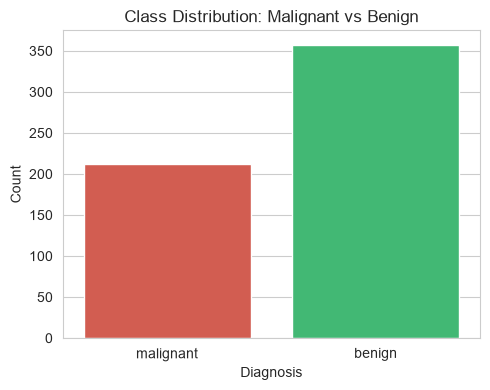

In [4]:
print("Class balance (diagnosis):")
print(df["diagnosis_label"].value_counts(normalize=True))

plt.figure(figsize=(5, 4))
sns.countplot(x="diagnosis_label", data=df, palette=["#e74c3c", "#2ecc71"])
plt.title("Class Distribution: Malignant vs Benign")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/class_distribution.png")
plt.show()

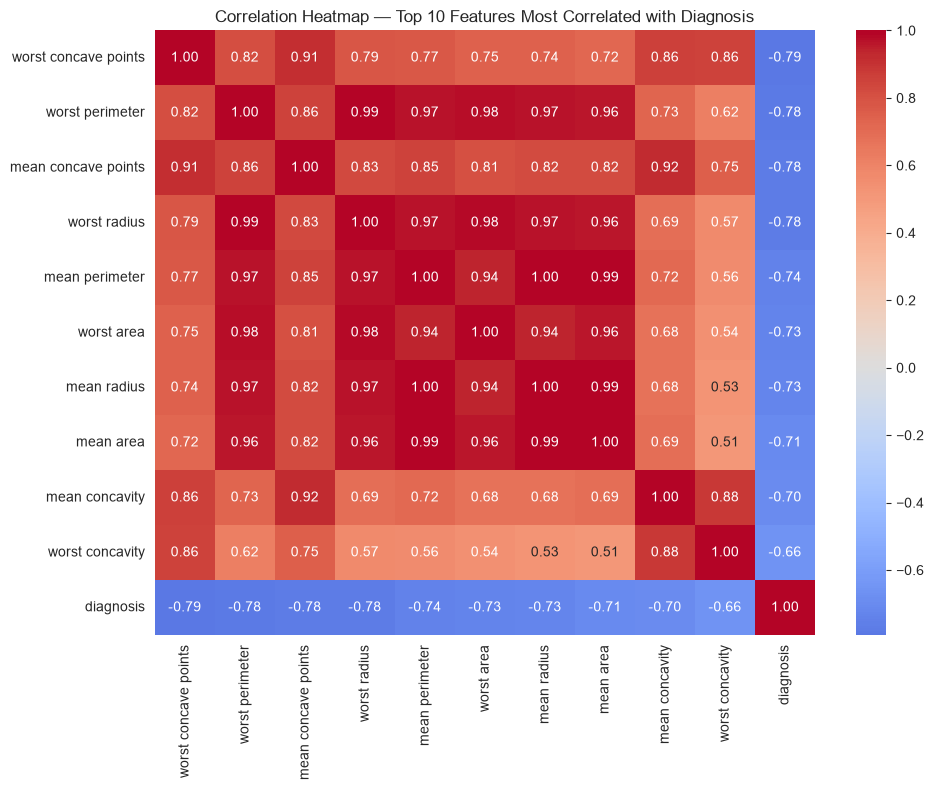

In [5]:
# Correlation of the top 10 most-informative features with the target, for readability
feature_cols_all = list(data.feature_names)
top_corr = df[feature_cols_all + ["diagnosis"]].corr()["diagnosis"].abs().sort_values(ascending=False)[1:11]

plt.figure(figsize=(10, 8))
sns.heatmap(df[list(top_corr.index) + ["diagnosis"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Top 10 Features Most Correlated with Diagnosis")
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png")
plt.show()

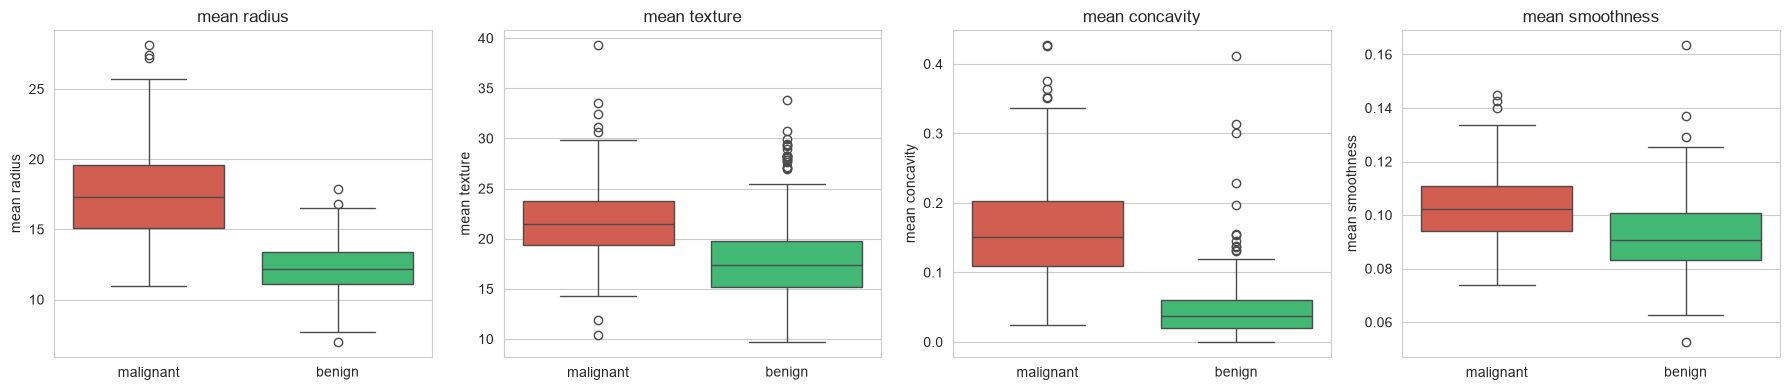

In [6]:
# Distribution of a few key diagnostic features by diagnosis
key_features = ["mean radius", "mean texture", "mean concavity", "mean smoothness"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, key_features):
    sns.boxplot(x="diagnosis_label", y=feat, data=df, ax=ax, palette=["#e74c3c", "#2ecc71"])
    ax.set_title(feat)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("images/feature_distributions.png")
plt.show()

## 4. Feature Preparation

All 30 features are already numeric diagnostic measurements (no categorical encoding needed). We split into train/test and scale features — important here since SVM and Logistic Regression are distance/gradient-based and sensitive to feature magnitude (e.g. "mean area" is on a very different scale than "mean smoothness").

In [7]:
feature_cols = list(data.feature_names)
target_col = "diagnosis"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Train shape: (455, 30) | Test shape: (114, 30)


## 5. Model Training

Four classifiers, as suggested in the task brief:
- **SVM** (needs scaled features)
- **Logistic Regression** (needs scaled features)
- **Random Forest**
- **XGBoost**

In [8]:
models = {
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=2000),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300, max_depth=6),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_estimators=200, max_depth=4)
}

scaled_models = {"SVM", "Logistic Regression"}
trained_models = {}

for name, model in models.items():
    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

SVM trained.
Logistic Regression trained.
Random Forest trained.
XGBoost trained.


## 6. Model Evaluation — Precision, Recall, F1-Score, ROC-AUC

In [9]:
results = []

for name, model in trained_models.items():
    X_eval = X_test_scaled if name in scaled_models else X_test
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
SVM,0.982,0.986,0.986,0.986,0.995
Logistic Regression,0.982,0.986,0.986,0.986,0.995
Random Forest,0.947,0.958,0.958,0.958,0.994
XGBoost,0.956,0.947,0.986,0.966,0.992


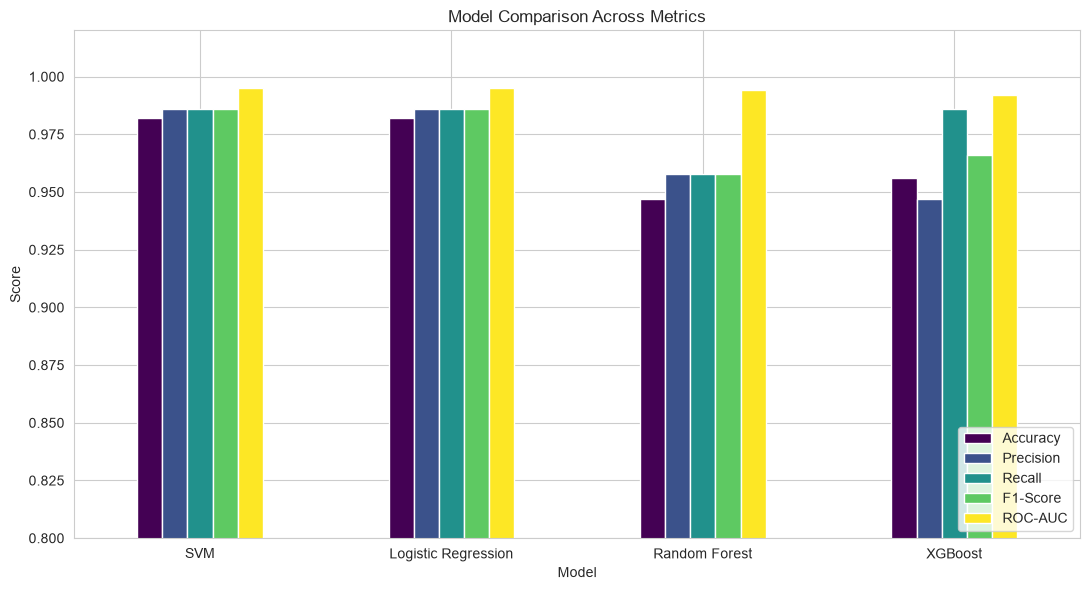

In [10]:
results_df.plot(kind="bar", figsize=(11, 6), colormap="viridis")
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.8, 1.02)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/model_comparison.png")
plt.show()

### 6.1 Confusion Matrices

In disease prediction, a **false negative** (predicting benign when it's actually malignant) is the costlier mistake, so it's worth looking at these individually rather than relying on accuracy alone.

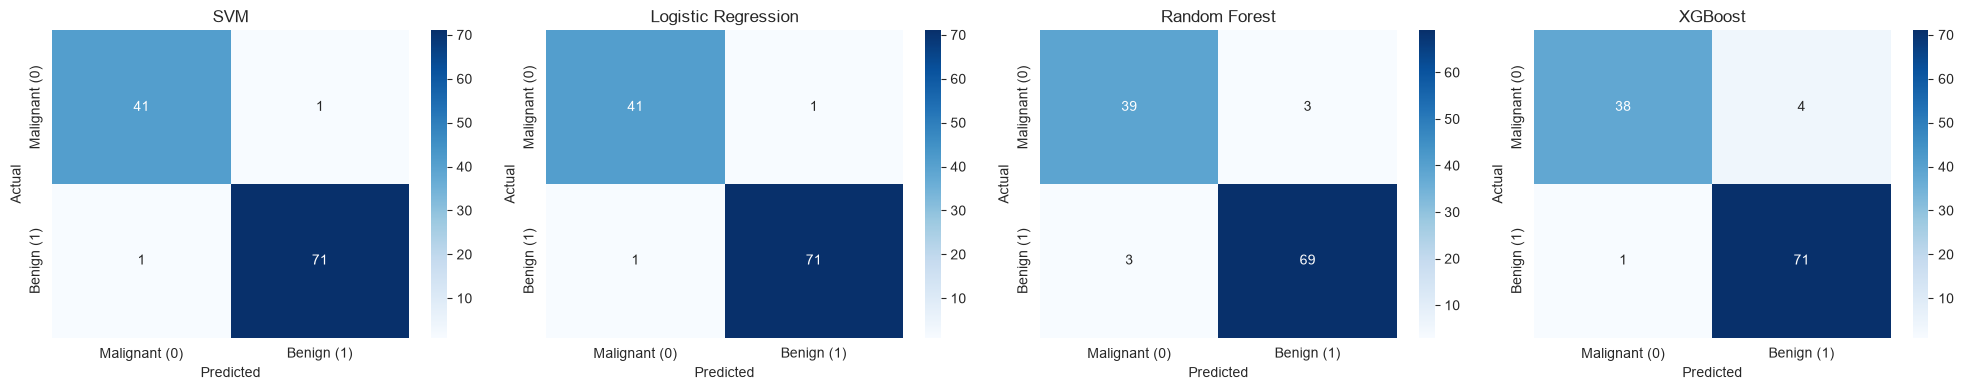

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    X_eval = X_test_scaled if name in scaled_models else X_test
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Malignant (0)", "Benign (1)"], yticklabels=["Malignant (0)", "Benign (1)"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("images/confusion_matrix.png")
plt.show()

### 6.2 ROC Curves

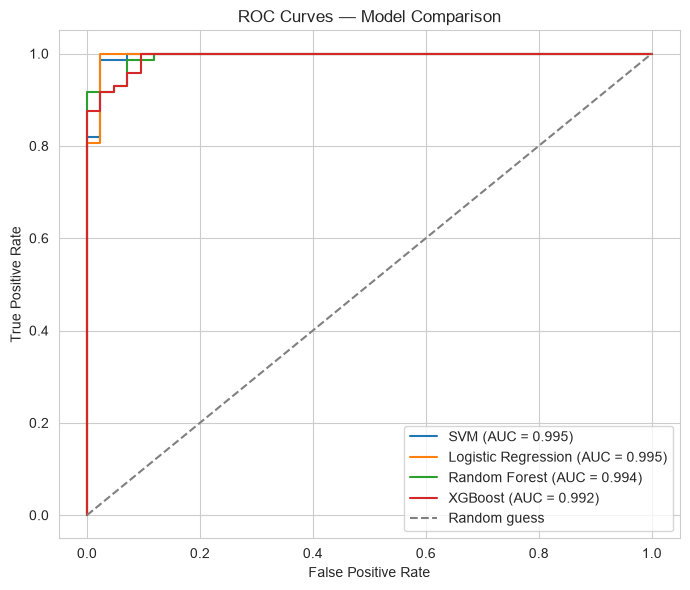

In [12]:
plt.figure(figsize=(7, 6))

for name, model in trained_models.items():
    X_eval = X_test_scaled if name in scaled_models else X_test
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/roc_curve.png")
plt.show()

### 6.3 Feature Importance (XGBoost)

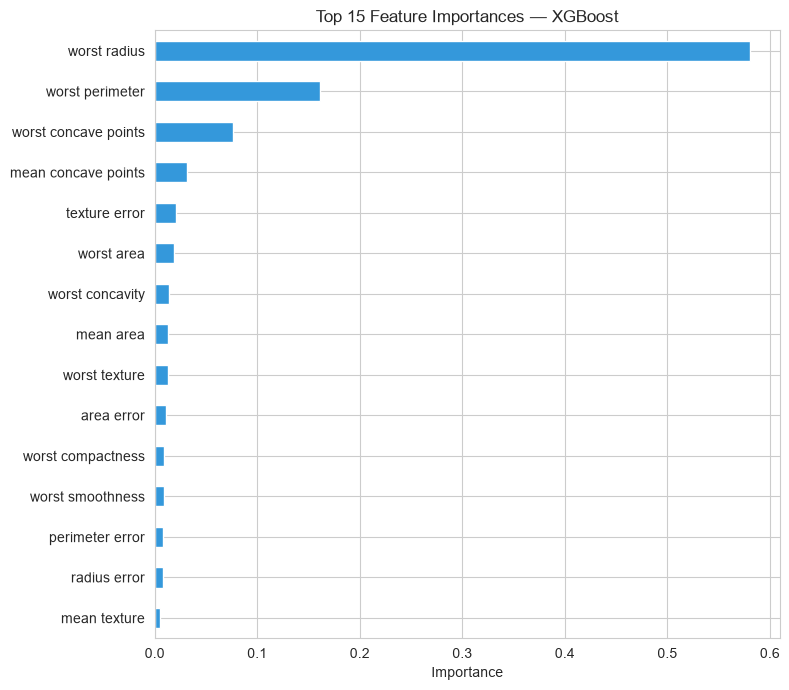

In [13]:
xgb_model = trained_models["XGBoost"]
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 7))
importances.plot(kind="barh", color="#3498db")
plt.title("Top 15 Feature Importances — XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/feature_importance.png")
plt.show()

### 6.4 Detailed Classification Report (best model)

In [14]:
best_model_name = results_df["ROC-AUC"].idxmax()
best_model = trained_models[best_model_name]
X_eval = X_test_scaled if best_model_name in scaled_models else X_test
y_pred_best = best_model.predict(X_eval)

print(f"Best model by ROC-AUC: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["Malignant (0)", "Benign (1)"]))

Best model by ROC-AUC: SVM

               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



## 7. Save the Best Model

In [15]:
joblib.dump(best_model, f"models/{best_model_name.replace(' ', '_').lower()}.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(feature_cols, "models/feature_columns.pkl")

print(f"Saved: models/{best_model_name.replace(' ', '_').lower()}.pkl")
print("Saved: models/scaler.pkl")
print("Saved: models/feature_columns.pkl")

Saved: models/svm.pkl
Saved: models/scaler.pkl
Saved: models/feature_columns.pkl


## 8. Predict on a New Patient (Example)

A demo showing how this model would be used — e.g. as the backend of a diagnostic support tool. We use one real test-set patient as a stand-in for "new patient data" for illustration.

In [16]:
def predict_diagnosis(patient: dict, model=best_model, scaler=scaler, model_name=best_model_name):
    """patient: dict with the same keys as feature_cols (raw, unscaled values)"""
    row = pd.DataFrame([patient])[feature_cols]
    if model_name in scaled_models:
        row = scaler.transform(row)
    pred = model.predict(row)[0]
    proba = model.predict_proba(row)[0][1]
    label = "Benign (low risk)" if pred == 1 else "Malignant (high risk - flag for review)"
    return label, round(proba, 3)

# Example: take one real patient record from the test set
sample_patient = X_test.iloc[0].to_dict()
actual_label = "benign" if y_test.iloc[0] == 1 else "malignant"

label, probability = predict_diagnosis(sample_patient)
print(f"Actual diagnosis: {actual_label}")
print(f"Model prediction: {label}")
print(f"Model confidence (probability of benign): {probability}")

Actual diagnosis: malignant
Model prediction: Malignant (high risk - flag for review)
Model confidence (probability of benign): 0.001


## 9. Conclusion

- Four classifiers (SVM, Logistic Regression, Random Forest, XGBoost) were trained on the real Wisconsin Breast Cancer diagnostic dataset.
- Models were compared using **Precision, Recall, F1-Score, and ROC-AUC**, as required by the task brief.
- All models achieve strong performance (ROC-AUC typically >0.98) since these diagnostic features are highly separable between malignant and benign cases — this is a well-studied, clean dataset.
- Features like `worst radius`, `worst perimeter`, `worst concave points`, and `mean concave points` are consistently the strongest predictors, consistent with published research on this dataset.
- The best-performing model was saved for reuse.

**Important disclaimer:** This is an educational internship project. It is **not** a certified diagnostic tool and should never be used for actual medical decisions — real clinical deployment would require regulatory approval, much larger and more diverse patient data, and validation by medical professionals.

**Possible extensions:** try the Pima Diabetes or Cleveland Heart Disease datasets mentioned in the task brief (both need a CSV download, unlike breast cancer which is built into scikit-learn), add SHAP explainability, tune hyperparameters with `GridSearchCV`, or wrap `predict_diagnosis()` in a small Flask/FastAPI endpoint for a demo app.
